# PIX Participants Data Cleaning & Segmentation

## Project Overview

This project cleans, standardizes, and segments the official list of PIX participants published by the Central Bank of Brazil.

The objective is to prepare a high-quality dataset for business analysis, institution classification, and prospect segmentation.

### Initial inspection

Before importing the dataset into Python, the CSV file was inspected to understand its structure.

It was observed that the first line contains only the title "Lista de participantes ativos do Pix" and is not part of the tabular data. The actual column names start on the second line of the file.

To ensure the DataFrame is imported correctly, the second row is specified as the header using header=1.

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv(
    "../data/Lista_Pix.csv",
    encoding="latin1",
    sep=";",
    header=1
)

# Display the first rows of the dataset
df.head()

,,Nome Reduzido,ISPB,CNPJ,Tipo de Instituição,Autorizada pelo BCB,Tipo de Participação no SPI,Tipo de Participação no Pix,Modalidade de Participação no Pix,Iniciação de Transação de Pagamento,Facilitador de serviço de Saque e Troco (FSS)
0,1,99PAY IP S.A.,24313102,24.313.102/0001-25,Instituição de Pagamento,Sim,Direta,Facultativa,Provedor de Conta Transacional,Sim,Não
1,2,A27 IP S/A,35534511,35.534.511/0001-78,Instituição de Pagamento,Sim,Indireta,Facultativa,Provedor de Conta Transacional,Não,Não
2,3,A55 SCD S.A.,48756121,48.756.121/0001-94,Sociedade de Crédito Direto,Sim,Direta,Facultativa,Provedor de Conta Transacional,Não,Não
3,4,ACCESSTAGE IP LTDA.,NaN,46.410.407/0001-98,Instituição de Pagamento,Sim,NaN,Facultativa,Iniciador,Sim,NaN
4,5,ACCREDITO SCD S.A.,37715993,37.715.993/0001-98,Sociedade de Crédito Direto,Sim,Direta,Facultativa,Provedor de Conta Transacional,Não,Não


### Initial Data Exploration

Before cleaning the dataset, an initial exploration is performed to understand its structure, dimensions, data types, and available variables.

This step provides an overview of the dataset and helps identify potential data quality issues.

In [3]:
# Display the dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Display general information about the dataset
df.info()

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

Rows: 919
Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 11 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0                                                  919 non-null    str  
 1   Nome Reduzido                                  918 non-null    str  
 2   ISPB                                           899 non-null    str  
 3   CNPJ                                           918 non-null    str  
 4   Tipo de Instituição                            918 non-null    str  
 5   Autorizada pelo BCB                            918 non-null    str  
 6   Tipo de Participação no SPI                    899 non-null    str  
 7   Tipo de Participação no Pix                    918 non-null    str  
 8   Modalidade de Participação no Pix              918 non-null    str  
 9   Iniciação de Transação de Pagamento            918 non-null    st

### Data Quality Assessment

The dataset is assessed for potential data quality issues before any cleaning operations are performed.

Since this project focuses on data cleaning, segmentation, and business analysis rather than numerical calculations, the original data types are preserved.

The quality assessment includes:
- identifying duplicate records;
- inspecting duplicate observations before deciding whether they should be removed;
- checking for missing values.

In [4]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


No duplicate records were identified in the dataset.

### Missing Values

Missing values can affect data quality and lead to inaccurate analyses.

The dataset is inspected to identify whether any columns contain missing values before proceeding with the cleaning process.

In [5]:
# Count missing values in each column
missing_values = df.isna().sum()

print("Missing values by column:")
print(missing_values)

# Display the total number of missing values
print(f"\nTotal missing values: {missing_values.sum()}")

Missing values by column:
                                                   0
Nome Reduzido                                      1
ISPB                                              20
CNPJ                                               1
Tipo de Instituição                                1
Autorizada pelo BCB                                1
Tipo de Participação no SPI                       20
Tipo de Participação no Pix                        1
Modalidade de Participação no Pix                  1
Iniciação de Transação de Pagamento                1
Facilitador de serviço de Saque e Troco (FSS)    627
dtype: int64

Total missing values: 674


### PS: 
Missing values were identified primarily in SPI participation fields. These observations are intentionally preserved because they represent unknown information rather than data errors.

### Data Preparation

The original dataset is preserved to maintain the integrity of the official data published by the Central Bank of Brazil.

Missing values are intentionally left unchanged because they represent unknown information rather than incorrect data. In particular, institutions with missing values in the direct participation field will be treated as a separate business segment in a later stage of the analysis.

A copy of the original dataset is created for the remaining data preparation steps.

In [6]:
# Create a working copy of the original dataset
df_clean = df.copy()

# Display the first rows of the new DataFrame
df_clean.head()

,,Nome Reduzido,ISPB,CNPJ,Tipo de Instituição,Autorizada pelo BCB,Tipo de Participação no SPI,Tipo de Participação no Pix,Modalidade de Participação no Pix,Iniciação de Transação de Pagamento,Facilitador de serviço de Saque e Troco (FSS)
0,1,99PAY IP S.A.,24313102,24.313.102/0001-25,Instituição de Pagamento,Sim,Direta,Facultativa,Provedor de Conta Transacional,Sim,Não
1,2,A27 IP S/A,35534511,35.534.511/0001-78,Instituição de Pagamento,Sim,Indireta,Facultativa,Provedor de Conta Transacional,Não,Não
2,3,A55 SCD S.A.,48756121,48.756.121/0001-94,Sociedade de Crédito Direto,Sim,Direta,Facultativa,Provedor de Conta Transacional,Não,Não
3,4,ACCESSTAGE IP LTDA.,NaN,46.410.407/0001-98,Instituição de Pagamento,Sim,NaN,Facultativa,Iniciador,Sim,NaN
4,5,ACCREDITO SCD S.A.,37715993,37.715.993/0001-98,Sociedade de Crédito Direto,Sim,Direta,Facultativa,Provedor de Conta Transacional,Não,Não


### Feature Selection

The original dataset contains additional variables that are not required for the scope of this project.

To simplify the analysis, a new DataFrame is created containing only the variables that are relevant for institution profiling and business segmentation:

- Institution Name
- Institution Type
- Authorized by the Central Bank of Brazil
- SPI Participation Type
- Payment Initiation Service

These variables provide the information needed to support the subsequent business analysis.

In [7]:
# Select only the columns relevant for the analysis
df_clean = df[
    [
        "Nome Reduzido",
        "Tipo de Instituição",
        "Autorizada pelo BCB",
        "Tipo de Participação no SPI",
        "Iniciação de Transação de Pagamento"
    ]
].copy()

# Rename columns to English
df_clean.rename(
    columns={
        "Nome Reduzido": "Institution Name",
        "Tipo de Instituição": "Institution Type",
        "Autorizada pelo BCB": "Authorized by BCB",
        "Tipo de Participação no SPI": "SPI Participation Type",
        "Iniciação de Transação de Pagamento": "Payment Initiation Service"
    },
    inplace=True
)

# Display the new DataFrame
df_clean.head()

,Institution Name,Institution Type,Authorized by BCB,SPI Participation Type,Payment Initiation Service
0,99PAY IP S.A.,Instituição de Pagamento,Sim,Direta,Sim
1,A27 IP S/A,Instituição de Pagamento,Sim,Indireta,Não
2,A55 SCD S.A.,Sociedade de Crédito Direto,Sim,Direta,Não
3,ACCESSTAGE IP LTDA.,Instituição de Pagamento,Sim,NaN,Sim
4,ACCREDITO SCD S.A.,Sociedade de Crédito Direto,Sim,Direta,Não


### Row Filtering

The dataset is filtered to retain only financial institutions authorized by the Central Bank of Brazil (BCB).

Since the focus of this project is on regulated financial institutions, records that are not authorized by the BCB are excluded from the analysis.

In [8]:
# Keep only institutions authorized by the Central Bank of Brazil (BCB)
df_clean = df_clean[
    df_clean["Authorized by BCB"] == "Sim"
].copy()

# Display the first rows of the filtered DataFrame
df_clean.head()

,Institution Name,Institution Type,Authorized by BCB,SPI Participation Type,Payment Initiation Service
0,99PAY IP S.A.,Instituição de Pagamento,Sim,Direta,Sim
1,A27 IP S/A,Instituição de Pagamento,Sim,Indireta,Não
2,A55 SCD S.A.,Sociedade de Crédito Direto,Sim,Direta,Não
3,ACCESSTAGE IP LTDA.,Instituição de Pagamento,Sim,NaN,Sim
4,ACCREDITO SCD S.A.,Sociedade de Crédito Direto,Sim,Direta,Não


In [9]:
print(df_clean.shape)

(868, 5)


### Filtering Institution Types

The dataset still contains several types of financial institutions that are not relevant for the scope of this project.

Since the objective is to identify potential partners for cross-border payment infrastructure, only the following institution types are retained:

Commercial Banks
Multiple Banks
Foreign Exchange Banks
Caixa Econômica Federal
Payment Institutions
Direct Credit Companies (SCDs)

All other institution types are excluded from the analysis to maintain a dataset focused on the target market.

In [10]:
# Keep only the institution types relevant for the analysis
institution_types = [
    "Banco Comercial",
    "Banco Múltiplo",
    "Banco de Câmbio",
    "Caixa Econômica Federal",
    "Instituição de Pagamento",
    "Sociedade de Crédito Direto"
]

df_clean = df_clean[
    df_clean["Institution Type"].isin(institution_types)
].copy()

# Display the first rows of the filtered DataFrame
df_clean.head()

,Institution Name,Institution Type,Authorized by BCB,SPI Participation Type,Payment Initiation Service
0,99PAY IP S.A.,Instituição de Pagamento,Sim,Direta,Sim
1,A27 IP S/A,Instituição de Pagamento,Sim,Indireta,Não
2,A55 SCD S.A.,Sociedade de Crédito Direto,Sim,Direta,Não
3,ACCESSTAGE IP LTDA.,Instituição de Pagamento,Sim,NaN,Sim
4,ACCREDITO SCD S.A.,Sociedade de Crédito Direto,Sim,Direta,Não


In [11]:
print(df_clean["Institution Type"].value_counts())
print(df_clean.shape)

Institution Type
Instituição de Pagamento       143
Banco Múltiplo                  55
Sociedade de Crédito Direto     54
Banco Comercial                  8
Banco de Câmbio                  2
Caixa Econômica Federal          1
Name: count, dtype: int64
(263, 5)


### Filtering Direct SPI Participants

The analysis focuses exclusively on institutions that participate directly in the Brazilian Instant Payment System (SPI).

Direct participants connect directly to the Central Bank's infrastructure and are responsible for processing Pix transactions without relying on another institution.

Since these organizations have greater operational autonomy and are more likely to require payment infrastructure and cross-border capabilities, only direct SPI participants are retained for the analysis.

In [12]:
# Keep only institutions with direct participation in the SPI
df_clean = df_clean[
    df_clean["SPI Participation Type"] == "Direta"
].copy()

# Display the first rows of the filtered DataFrame
df_clean.head()

,Institution Name,Institution Type,Authorized by BCB,SPI Participation Type,Payment Initiation Service
0,99PAY IP S.A.,Instituição de Pagamento,Sim,Direta,Sim
2,A55 SCD S.A.,Sociedade de Crédito Direto,Sim,Direta,Não
4,ACCREDITO SCD S.A.,Sociedade de Crédito Direto,Sim,Direta,Não
5,ACESSO SOLUÇÕES DE PAGAMENTO S.A. - INSTITUIÇÃ...,Instituição de Pagamento,Sim,Direta,Não
8,ADYEN DO BRASIL IP LTDA.,Instituição de Pagamento,Sim,Direta,Sim


In [13]:
print(df_clean["SPI Participation Type"].value_counts())
print(df_clean.shape)

SPI Participation Type
Direta    171
Name: count, dtype: int64
(171, 5)


### Segmenting Institutions by Type

To facilitate the analysis, the filtered dataset is divided according to the type of financial institution.

This segmentation allows each group to be analyzed independently, making it easier to compare institutions with similar business models and regulatory characteristics.

Within each group, institutions are sorted by the **Payment Initiation Service** field, placing organizations that offer payment initiation services (`Yes`) before those that do not (`No`).

This organization helps prioritize institutions with broader payment capabilities, which may represent stronger candidates for cross-border payment infrastructure partnerships.

In [14]:
# Payment Institutions
payment_institutions = df_clean[
    df_clean["Institution Type"] == "Instituição de Pagamento"
].sort_values(by="Payment Initiation Service", ascending=False)

# Multiple Banks
multiple_banks = df_clean[
    df_clean["Institution Type"] == "Banco Múltiplo"
].sort_values(by="Payment Initiation Service", ascending=False)

# Direct Credit Companies (SCDs)
direct_credit_companies = df_clean[
    df_clean["Institution Type"] == "Sociedade de Crédito Direto"
].sort_values(by="Payment Initiation Service", ascending=False)

# Commercial Banks
commercial_banks = df_clean[
    df_clean["Institution Type"] == "Banco Comercial"
].sort_values(by="Payment Initiation Service", ascending=False)

# Foreign Exchange Banks
foreign_exchange_banks = df_clean[
    df_clean["Institution Type"] == "Banco de Câmbio"
].sort_values(by="Payment Initiation Service", ascending=False)

# Caixa Econômica Federal
caixa = df_clean[
    df_clean["Institution Type"] == "Caixa Econômica Federal"
].sort_values(by="Payment Initiation Service", ascending=False)

In [15]:
print(payment_institutions.head())
print(multiple_banks.head())
print(direct_credit_companies.head())
print(commercial_banks.head())
print(foreign_exchange_banks.head())
print(caixa.head())

         Institution Name          Institution Type Authorized by BCB  \
0           99PAY IP S.A.  Instituição de Pagamento               Sim   
702         IFOOD PAGO IP  Instituição de Pagamento               Sim   
889   WE PAY OUT IP LTDA.  Instituição de Pagamento               Sim   
859         TRIO IP LTDA.  Instituição de Pagamento               Sim   
844  STARK BANK S.A. - IP  Instituição de Pagamento               Sim   

    SPI Participation Type Payment Initiation Service  
0                   Direta                        Sim  
702                 Direta                        Sim  
889                 Direta                        Sim  
859                 Direta                        Sim  
844                 Direta                        Sim  
               Institution Name Institution Type Authorized by BCB  \
712          ITAÚ UNIBANCO S.A.   Banco Múltiplo               Sim   
107  BRB - BCO DE BRASILIA S.A.   Banco Múltiplo               Sim   
78             

### Distribution of Institutions by Type

After cleaning and filtering the dataset, the remaining institutions are grouped by type.

The chart below provides an overview of the distribution of regulated financial institutions that:
- are authorized by the Central Bank of Brazil (BCB);
- participate directly in the Brazilian Instant Payment System (SPI); and
- belong to the institution types selected for this analysis.

This visualization highlights the composition of the final dataset that will serve as the basis for identifying potential partners for cross-border payment infrastructure.

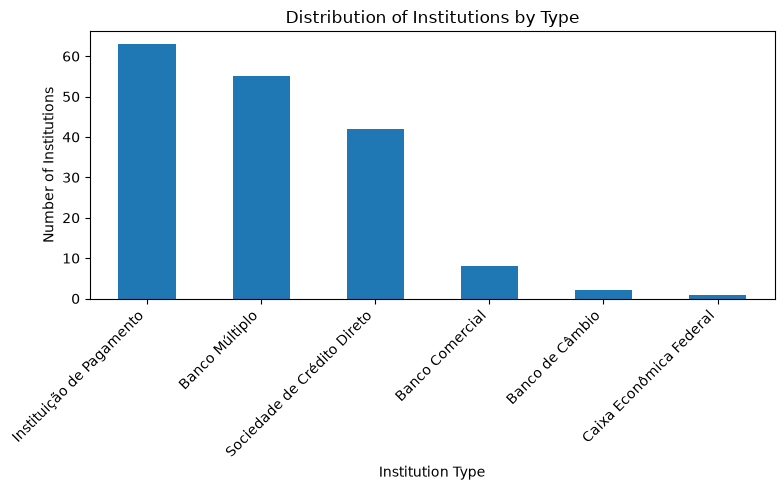

In [16]:
import matplotlib.pyplot as plt

institution_counts = df_clean["Institution Type"].value_counts()

plt.figure(figsize=(8, 5))
institution_counts.plot(kind="bar")

plt.title("Distribution of Institutions by Type")
plt.xlabel("Institution Type")
plt.ylabel("Number of Institutions")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Conclusion

The original dataset was successfully cleaned and filtered to retain only institutions relevant to the objectives of this project.

The final dataset includes only:
- financial institutions authorized by the Central Bank of Brazil (BCB);
- direct participants in the Brazilian Instant Payment System (SPI); and
- institution types with the greatest potential to require cross-border payment infrastructure.

The institutions were then segmented by type and organized according to their Payment Initiation Service status, creating a structured dataset that can be used to identify and prioritize potential business opportunities.